# Professional Dataset Preprocessing: From Raw Data to ML-Ready (Titanic)

## Dataset Name & Origin
**Dataset:** Titanic (passenger manifest + survival outcome)  
**Origin:** Kaggle’s classic Titanic competition dataset (a curated version is also distributed through other learning resources).

## Real-World Interpretation of the Problem
We want to predict whether a passenger **survived** the Titanic disaster based on information available about them (ticket class, age, sex, fare, family aboard, embarkation port, etc.).

This is analogous to many real-world problems:
- predicting churn or conversion from customer attributes
- predicting default risk from applicant data
- predicting medical outcome from patient characteristics

## Why This Dataset Is Ideal for Learning Preprocessing
Titanic is *not clean* and contains the exact imperfections you must learn to handle:
- **Missing values** (e.g., Age, Cabin, Embarked)
- **Mixed feature types** (numerical + categorical + text-like identifiers)
- **Outliers** and extreme values (Fare)
- **Skewed distributions** (Fare is heavily right-skewed)
- **Leakage traps / non-generalizable signals** (PassengerId, Name patterns, Ticket/Cabin high-cardinality artifacts)
- **Realistic semantics** (some “numbers” should be treated as categories)

> This notebook is **NOT** about building the best model.  
> It is about learning to think correctly about data before ML.


## 2 Learning Objectives
After completing this notebook, you will be able to:

1. **Perform first-contact diagnostics** (shape, types, suspicious columns, early warnings).
2. **Identify data quality issues**: missing values, wrong dtypes, duplicates, impossible values.
3. **Choose preprocessing strategies intentionally** (not by habit) and explain trade-offs.
4. **Handle categorical variables safely** (cardinality, rare categories, encoding options + leakage risks).
5. **Handle numerical features professionally** (distributions, outliers, scaling choices, log transforms).
6. **Prevent leakage** by splitting first and fitting preprocessors only on training data.
7. Build a clean **scikit-learn Pipeline + ColumnTransformer** that outputs ML-ready matrices.
8. Perform sanity checks to confirm data is truly ML-ready.


## 3 Dataset Loading & First Contact


In [ ]:
# Required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, FunctionTransformer

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

# --- Load Titanic ---
# We'll try: (1) seaborn built-in dataset, then (2) fallback to an online CSV if needed.

df = None
try:
    df = sns.load_dataset('titanic')
    source_used = "seaborn.load_dataset('titanic')"
except Exception as e:
    source_used = "FAILED: seaborn.load_dataset('titanic')"
    print("Seaborn load failed:", repr(e))

if df is None:
    raise RuntimeError(
        "Dataset loading failed. If you are offline, use a local CSV of Titanic (train.csv from Kaggle) and load with pd.read_csv."
    )

print("Loaded from:", source_used)
df.head(10)


Loaded from: seaborn.load_dataset('titanic')


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [2]:
# Shape, columns, dtypes
print("Shape:", df.shape)
display(df.dtypes)
display(df.head(5))

# First-contact summary
df.info()


Shape: (891, 15)


survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### First Contact: Slow Down and Look for Early Warnings
Before you touch any preprocessing function:

- Which columns look like **identifiers** (unique values per row)?
- Which columns are **obviously categorical** but stored as numbers?
- Which columns have **missing values**?
- Any columns that look like **post-outcome information** (leakage risk)?
- Any columns with **high cardinality** (many unique categories)?

In real projects, rushing here is how you end up with:
- leakage
- broken train/test evaluation
- unstable production behavior
- meaningless features


In [3]:
# Quick suspicion checks

n = len(df)
uniques = df.nunique(dropna=False).sort_values(ascending=False)
suspect_identifiers = uniques[uniques > 0.9 * n]

print("Potential identifier-like columns (unique values ~ number of rows):")
display(suspect_identifiers)

print("\nUnique counts (top 15):")
display(uniques.head(15))

print("\nMissing values per column (count):")
display(df.isna().sum().sort_values(ascending=False))


Potential identifier-like columns (unique values ~ number of rows):


Series([], dtype: int64)


Unique counts (top 15):


fare           248
age             89
deck             8
parch            7
sibsp            7
embarked         4
embark_town      4
who              3
class            3
pclass           3
sex              2
survived         2
adult_male       2
alive            2
alone            2
dtype: int64


Missing values per column (count):


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

## 4 Target Variable & Problem Framing
### Identify the target
In Titanic, the typical target is **survival**.

### Classification or regression?
- Survival is **binary** ⇒ **classification**.

### Pitfalls to check right away
- **Class imbalance**: if one class dominates, accuracy can lie.
- **Leakage**: any feature that is derived from or recorded after survival should not be used.
- **Train/test mismatch**: categories present in test but not train.


Target distribution:


survived
0    549
1    342
Name: count, dtype: int64

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

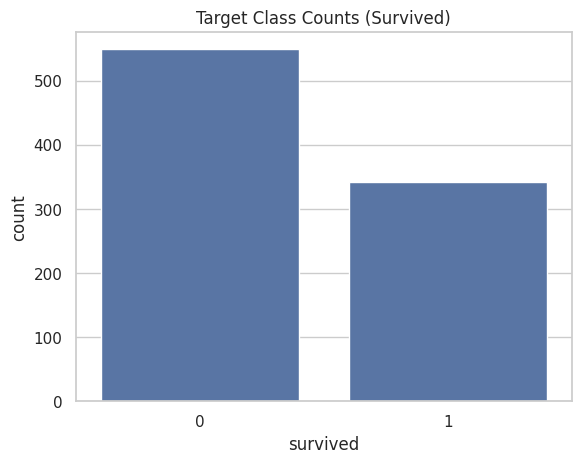

In [ ]:
# Identify target
# In seaborn Titanic, the target column is usually 'survived' (0/1).
target_col = 'survived'

if target_col not in df.columns:
    raise ValueError(f"Expected target column '{target_col}' not found. Available columns: {list(df.columns)}")

y = df[target_col]
X = df.drop(columns=[target_col])

print("Target distribution:")
display(y.value_counts(dropna=False))
display(y.value_counts(normalize=True, dropna=False).rename('proportion'))

# Visualize imbalance
plt.figure()
sns.countplot(x=y)
plt.title("Target Class Counts (Survived)")
plt.show()


## 5 Missing Values — Deep & Exhaustive
This section is deliberately long because **missing values are never just a technical problem**.

### Step 1: Measure missingness
We will compute both **counts** and **percentages** per column.

### Step 2: Think about why values are missing
Missingness has different causes:
- **MCAR** (Missing Completely At Random): rare, safest
- **MAR** (Missing At Random): depends on observed variables (common)
- **MNAR** (Missing Not At Random): depends on unobserved value itself (very common in reality)

We won’t do math here, but we WILL reason about causes and consequences.

### Step 3: Consider all reasonable solutions
For each column with missing values, we must consider:

1. **Drop rows** (only when few missing and not systematic)
2. **Drop column** (when too missing or not valuable)
3. **Simple imputation** (mean/median/mode)
4. **Group-wise imputation** (impute within groups like class/sex)
5. **Model-based imputation** (conceptual here: KNNImputer, iterative imputation)
6. **Leave missing** (some models can handle missing, or missing is informative)
7. **Add missingness indicator** (often powerful: missingness itself can be signal)

> The most important rule:  
**Do not decide imputation before splitting train/test.**


## 5 Missing Values — Deep & Exhaustive
This section is deliberately long because **missing values are never just a technical problem**.

### Step 1: Measure missingness
We will compute both **counts** and **percentages** per column.

### Step 2: Think about why values are missing
Missingness has different causes:
- **MCAR** (Missing Completely At Random): rare, safest
- **MAR** (Missing At Random): depends on observed variables (common)
- **MNAR** (Missing Not At Random): depends on unobserved value itself (very common in reality)

We won’t do math here, but we WILL reason about causes and consequences.

### Step 3: Consider all reasonable solutions
For each column with missing values, we must consider:

1. **Drop rows** (only when few missing and not systematic)
2. **Drop column** (when too missing or not valuable)
3. **Simple imputation** (mean/median/mode)
4. **Group-wise imputation** (impute within groups like class/sex)
5. **Model-based imputation** (conceptual here: KNNImputer, iterative imputation)
6. **Leave missing** (some models can handle missing, or missing is informative)
7. **Add missingness indicator** (often powerful: missingness itself can be signal)

> The most important rule:  
**Do not decide imputation before splitting train/test.**


,missing_count,missing_pct
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


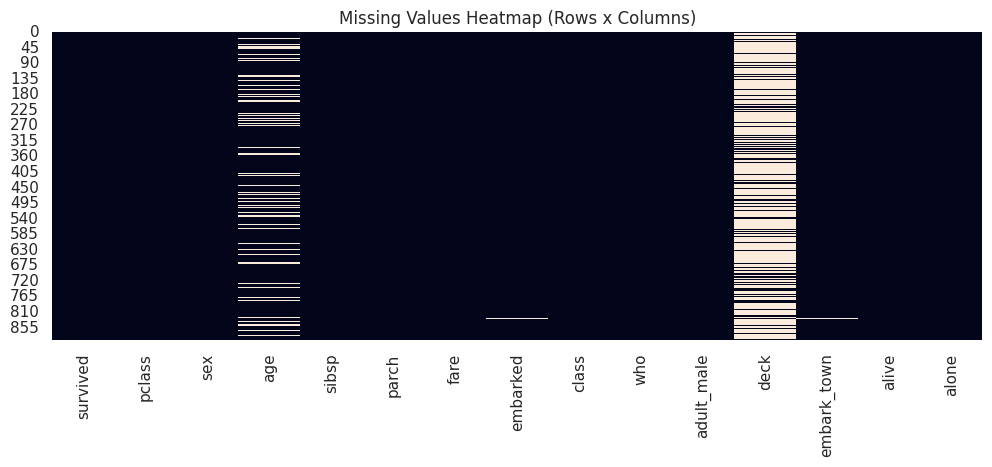

In [21]:
# Missingness table
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100

missing_table = (
    pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
      .sort_values('missing_pct', ascending=False)
)

display(missing_table)

# Visualize missingness (heatmap sample)
plt.figure(figsize=(12, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap (Rows x Columns)")
plt.show()


### Columns with Missing Values: Column-by-Column Reasoning

We will examine each column with missing values and discuss:
- how much is missing
- why it might be missing
- which solutions are reasonable
- which solution we choose and why

⚠️ Note: Seaborn’s Titanic includes features like `deck`, `embark_town`, `age`, `embarked`, etc.
If you use Kaggle’s `train.csv`, you will see `Cabin` (very missing), `Age`, `Embarked`, etc.
The reasoning is the same.


In [5]:
missing_cols = missing_table[missing_table['missing_count'] > 0].index.tolist()
print("Columns with missing values:", missing_cols)

# For each missing column, show basic stats and a quick look
for col in missing_cols:
    print("\n" + "="*80)
    print(f"Column: {col}")
    print(f"Missing: {missing_table.loc[col, 'missing_count']} ({missing_table.loc[col, 'missing_pct']:.2f}%)")
    print("Dtype:", df[col].dtype)
    display(df[col].head(10))
    if df[col].dtype == 'object' or str(df[col].dtype).startswith('category'):
        display(df[col].value_counts(dropna=False).head(10))
    else:
        display(df[col].describe())


Columns with missing values: ['deck', 'age', 'embarked', 'embark_town']

Column: deck
Missing: 688 (77.22%)
Dtype: category


0    NaN
1      C
2    NaN
3      C
4    NaN
5    NaN
6      E
7    NaN
8    NaN
9    NaN
Name: deck, dtype: category
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64


Column: age
Missing: 177 (19.87%)
Dtype: float64


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

...

0    S
1    C
2    S
3    S
4    S
5    Q
6    S
7    S
8    S
9    C
Name: embarked, dtype: object

embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


Column: embark_town
Missing: 2 (0.22%)
Dtype: object


0    Southampton
1      Cherbourg
2    Southampton
3    Southampton
4    Southampton
5     Queenstown
6    Southampton
7    Southampton
8    Southampton
9      Cherbourg
Name: embark_town, dtype: object

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

### A Professional Missing-Value Playbook (with examples)

Below are **all reasonable solutions**, with **when to use** and **when NOT to use**.
We will demonstrate them with real code patterns.

#### (A) Drop rows
**Use when:**
- missing is very small (e.g., <1–3%)
- missing appears random (not correlated with target or key groups)
- you can afford to lose data

**Do NOT use when:**
- missing is large
- missing is systematic (e.g., all from a subgroup)
- dropping changes the population (bias)

#### (B) Drop columns
**Use when:**
- extreme missingness (e.g., 60–90%)
- column is weakly useful or high leakage risk
- too expensive to impute reliably

**Do NOT use when:**
- column is critical (e.g., medically important feature)
- missingness itself is informative and can be modeled

#### (C) Simple imputation (mean/median/mode)
**Use when:**
- numeric feature, moderate missingness
- distribution not too weird (or you use median for robustness)
- you accept reduced variance

**Do NOT use when:**
- missingness is highly nonrandom
- feature is categorical encoded as numbers
- outliers/skew make mean inappropriate

#### (D) Group-wise imputation
**Use when:**
- feature depends on other known variables (Age depends on class/sex)
- you can justify groups from domain knowledge

**Do NOT use when:**
- groups are too small → noisy imputation
- grouping variable leaks target

#### (E) Model-based imputation (conceptual)
Examples: KNNImputer, IterativeImputer.
**Use when:**
- missingness is moderate
- relationships between features help predict missing values

**Do NOT use when:**
- risk of leakage (if model sees target or post-outcome features)
- small datasets with unstable imputation

#### (F) Leave missing (only sometimes valid)
**Use when:**
- models that natively handle missing (some tree implementations)
- missingness is meaningful, and you preserve it

**Do NOT use when:**
- most ML pipelines require numeric arrays with no NaNs

#### (G) Add missingness indicator
Often powerful: add a boolean column `col_is_missing`.
**Use when:**
- missingness might be informative (e.g., cabin unknown correlates with class)

**Do NOT use when:**
- missingness is truly random AND you want simpler models (still often harmless)


In [7]:
# Demonstration patterns (NOT final decisions yet)

# A) Drop rows with missing values in selected columns (example)
example_cols = missing_cols[:2] if len(missing_cols) >= 2 else missing_cols
df_drop_rows = df.dropna(subset=example_cols) if example_cols else df.copy()
print("Original shape:", df.shape)
print("After dropping rows with missing in", example_cols, ":", df_drop_rows.shape)

# B) Drop a column with too many missing values (example)
if missing_cols:
    worst_col = missing_table.index[0]
    df_drop_col = df.drop(columns=[worst_col])
    print(f"\nDropping worst missingness column '{worst_col}':")
    print("New shape:", df_drop_col.shape)

# C) Simple imputation for numeric (example)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_missing = [c for c in numeric_cols if df[c].isna().any()]

if numeric_missing:
    col = numeric_missing[0]
    median_val = df[col].median()
    df_median_imputed = df.copy()
    df_median_imputed[col] = df_median_imputed[col].fillna(median_val)
    print(f"\nMedian imputation example for '{col}': median={median_val}")
    print("Missing before:", df[col].isna().sum(), "after:", df_median_imputed[col].isna().sum())

# D) Group-wise imputation (example: age by sex + class if available)
df_group_imputed = df.copy()
if 'age' in df.columns:
    group_cols = [c for c in ['sex', 'class'] if c in df.columns]
    if group_cols:
        df_group_imputed['age'] = df_group_imputed['age'].fillna(
            df_group_imputed.groupby(group_cols)['age'].transform('median')
        )
        print("\nGroup-wise imputation for 'age' using groups:", group_cols)
        print("Missing after:", df_group_imputed['age'].isna().sum())

# G) Missingness indicator (example)
df_indicator = df.copy()
for col in missing_cols:
    df_indicator[col + '_is_missing'] = df_indicator[col].isna().astype(int)
print("\nAdded missingness indicators for:", missing_cols)
display(df_indicator[[c for c in df_indicator.columns if c.endswith('_is_missing')]].head())


Original shape: (891, 15)
After dropping rows with missing in ['deck', 'age'] : (184, 15)

Dropping worst missingness column 'deck':
New shape: (891, 14)

Median imputation example for 'age': median=28.0
Missing before: 177 after: 0

Group-wise imputation for 'age' using groups: ['sex', 'class']
Missing after: 0

Added missingness indicators for: ['deck', 'age', 'embarked', 'embark_town']


/tmp/ipykernel_48361/213954827.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_group_imputed.groupby(group_cols)['age'].transform('median')


,deck_is_missing,age_is_missing,embarked_is_missing,embark_town_is_missing
0,1,0,0,0
1,0,0,0,0
2,1,0,0,0
3,0,0,0,0
4,1,0,0,0


### Which missing-value strategies will we choose (and WHY)?
In this notebook, we will make *defensible* choices typical for a baseline production pipeline:

- **Drop columns that are mostly missing or act as unstable high-cardinality proxies** (in Kaggle Titanic, `Cabin` often falls here; in seaborn Titanic, `deck` is often heavily missing).  
  *Reason:* extremely missing and often acts like an encoded proxy for wealth/class; you can keep it only if you handle it carefully.

- For **Age**: use **median imputation** (robust) + optionally **missingness indicator**.
  *Reason:* age is important, missingness is moderate, median is robust.

- For **Embarked / embark_town** (categorical): use **most_frequent** imputation.
  *Reason:* small missingness, simplest stable option.

We will implement these choices correctly using a **Pipeline** (imputer fitted only on training data).


## 6 Data Types & Semantic Meaning
A common real-world failure: confusing **technical types** with **semantic types**.

Examples:
- A column stored as integer might actually be a **category** (e.g., passenger class).
- A string column might be an **identifier** (ticket number) not a category you should one-hot.
- A boolean might be stored as object due to mixed values.
- Dates might be strings and need parsing.

We will:
- Detect wrong dtypes
- Convert safely
- Decide whether numeric-like columns should be treated as categorical


In [8]:
# Inspect dtypes and candidates for semantic type changes
display(df.dtypes)

# Heuristic: integer columns with small number of unique values might be categorical
int_cols = df.select_dtypes(include=['int64', 'int32']).columns.tolist()
candidate_categorical = []
for col in int_cols:
    if df[col].nunique(dropna=False) <= 15:
        candidate_categorical.append(col)

print("Integer columns that may be categorical (<=15 unique):", candidate_categorical)

# Show unique values for these candidates
for col in candidate_categorical:
    print("\n", col, "unique values:")
    display(sorted(df[col].dropna().unique().tolist())[:30])


survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Integer columns that may be categorical (<=15 unique): ['survived', 'pclass', 'sibsp', 'parch']

 survived unique values:


[0, 1]


 pclass unique values:


[1, 2, 3]


 sibsp unique values:


[0, 1, 2, 3, 4, 5, 8]


 parch unique values:


[0, 1, 2, 3, 4, 5, 6]

### Decide semantic conversions
We will **not** blindly convert everything.

Professional approach:
- Convert when:
  - it improves the modeling meaning
  - it prevents incorrect scaling
  - it prevents treating IDs as categories

Examples in Titanic variants:
- `pclass` is often numeric but should be **categorical/ordinal**.
- `sibsp`, `parch` are counts (numeric), but small-integer counts can still be numeric.
- `who`, `adult_male`, `alone` are semantic categories/booleans.

We will handle these decisions mainly through **column selection** and encoding choices in the pipeline.


## 7 Duplicates & Invalid Data
Two different problems:

### A) Duplicates
- Exact duplicate rows
- Duplicate IDs (if you have an ID column)
- Near-duplicates (harder; not covered fully here)

### B) Invalid / Impossible values
You must use domain reasoning:
- Age cannot be negative
- Fare cannot be negative
- A passenger cannot have negative family count

> In real projects, invalid values often come from data entry errors or ETL bugs.


In [9]:
# Duplicate rows
dup_count = df.duplicated().sum()
print("Exact duplicate rows:", dup_count)

if dup_count > 0:
    display(df[df.duplicated()].head())

# Invalid values checks (only for columns that exist)
checks = []

if 'age' in df.columns:
    checks.append(('age_negative', (df['age'] < 0).sum()))
    checks.append(('age_extreme', (df['age'] > 100).sum()))  # not impossible, but suspicious

if 'fare' in df.columns:
    checks.append(('fare_negative', (df['fare'] < 0).sum()))

# seaborn titanic uses 'parch' and 'sibsp'
for col in ['sibsp', 'parch']:
    if col in df.columns:
        checks.append((f'{col}_negative', (df[col] < 0).sum()))

display(pd.DataFrame(checks, columns=['check', 'count']))


Exact duplicate rows: 107


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,check,count
0,age_negative,0
1,age_extreme,0
2,fare_negative,0
3,sibsp_negative,0
4,parch_negative,0


### Decision: Remove duplicates?
If exact duplicates exist, you typically remove them **unless** duplicates represent real repeated events.

In Titanic, duplicates would likely be accidental (one passenger shouldn’t appear twice), so removal is generally safe.

We will not remove duplicates here unless we actually find them — but we will show how.


In [10]:
# Remove duplicates if present (demonstration)
df_nodup = df.drop_duplicates()
print("Shape before:", df.shape)
print("Shape after drop_duplicates:", df_nodup.shape)


Shape before: (891, 15)
Shape after drop_duplicates: (784, 15)


## 8 Categorical Variables Handling
Categorical handling is where many real systems fail.

For EACH categorical feature we will:
- analyze cardinality (how many unique categories)
- look at rare categories
- discuss encoding options:
  - Label Encoding
  - One-Hot Encoding
  - Ordinal Encoding
  - Target Encoding (conceptual)

### Why cardinality matters
- High-cardinality one-hot can explode dimensionality
- Rare categories cause unstable estimates
- Some categories appear only in test ⇒ risk if not handled

### Leakage dangers
Target encoding can leak target information if done incorrectly (fitted before split).


In [24]:
# Identify categorical columns (object/category/bool)
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# Cardinality analysis
cardinality = pd.DataFrame({
    'n_unique': X[cat_cols].nunique(dropna=False),
    'missing_pct': (X[cat_cols].isna().mean() * 100)
}).sort_values('n_unique', ascending=False)

display(cardinality)


Categorical columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Numerical columns: ['pclass', 'age', 'sibsp', 'parch', 'fare']


,n_unique,missing_pct
deck,8,77.216611
embark_town,4,0.224467
embarked,4,0.224467
who,3,0.000000
class,3,0.000000
sex,2,0.000000
adult_male,2,0.000000
alive,2,0.000000
alone,2,0.000000


In [25]:
# Rare category analysis
# We'll display top categories and how many are rare (< 1% of rows)
rare_threshold = 0.01

for col in cat_cols:
    vc = X[col].value_counts(dropna=False)
    prop = vc / len(X)
    n_rare = (prop < rare_threshold).sum()
    print("\n" + "="*80)
    print(f"Column: {col}")
    print("Unique categories (incl NaN):", X[col].nunique(dropna=False))
    print(f"# Rare categories (<{rare_threshold*100:.1f}%):", n_rare)
    display(pd.DataFrame({'count': vc, 'proportion': prop}).head(10))



Column: sex
Unique categories (incl NaN): 2
# Rare categories (<1.0%): 0


,count,proportion
sex,,
male,577,0.647587
female,314,0.352413



Column: embarked
Unique categories (incl NaN): 4
# Rare categories (<1.0%): 1


,count,proportion
embarked,,
S,644,0.722783
C,168,0.188552
Q,77,0.086420
NaN,2,0.002245



Column: class
Unique categories (incl NaN): 3
# Rare categories (<1.0%): 0


...

,count,proportion
embark_town,,
Southampton,644,0.722783
Cherbourg,168,0.188552
Queenstown,77,0.086420
NaN,2,0.002245



Column: alive
Unique categories (incl NaN): 2
# Rare categories (<1.0%): 0


,count,proportion
alive,,
no,549,0.616162
yes,342,0.383838



Column: alone
Unique categories (incl NaN): 2
# Rare categories (<1.0%): 0


,count,proportion
alone,,
True,537,0.602694
False,354,0.397306


### Encoding Options (Compare + Risks)

#### 1) Label Encoding (concept)
Maps categories to integers: `A→0, B→1, C→2`.
- ✅ simple
- ❌ introduces fake order (dangerous for nominal categories)
- ✅ sometimes OK for tree models *if* order doesn’t matter, but still risky

#### 2) One-Hot Encoding (we will use this)
Creates a binary column per category.
- ✅ safe for nominal categories
- ✅ common baseline
- ❌ increases dimensionality
- ✅ with `handle_unknown='ignore'` it survives unseen test categories

#### 3) Ordinal Encoding
Maps categories to integers BUT you must justify an order.
- ✅ good for ordered categories (e.g., `class`: Third < Second < First)
- ❌ wrong if no true order

#### 4) Target Encoding (conceptual, no math)
Replace each category with a statistic of the target (like mean survival rate per category).
- ✅ powerful
- ❌ **HIGH leakage risk** if computed using full dataset
- ✅ must be done with cross-validation or inside the training fold only

### Final choice for this notebook
We will use:
- **OneHotEncoder** for most categorical variables
- Optionally treat an ordered column (like `class`) with **OrdinalEncoder** if we choose to.

We will also discuss **rare category handling**:
- group rare categories into `"Other"`
- or keep them if cardinality is manageable


## 9 Numerical Features & Scaling
For numerical features we will:
- plot distributions
- detect skewness
- detect outliers (visual + IQR rule)
- discuss scaling choices

### Scaling options (when to use)
- **No scaling**: tree-based models often fine; counts may not need scaling.
- **StandardScaler**: sensitive models (linear models, SVM, KNN, neural nets) often prefer it.
- **MinMaxScaler**: when you need bounded features (some NN setups).
- **RobustScaler**: best when outliers exist.
- **Log transform**: for heavy right-skew (Fare). Helps stabilize variance.

### Important:
Scaling is not “always good”. It can be harmful:
- if you scale binary indicators (sometimes fine but interpretability changes)
- if you scale leakage features (still leakage)
- if you fit scaler on full data (leakage)


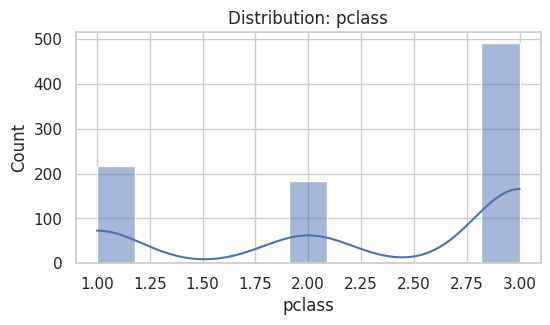

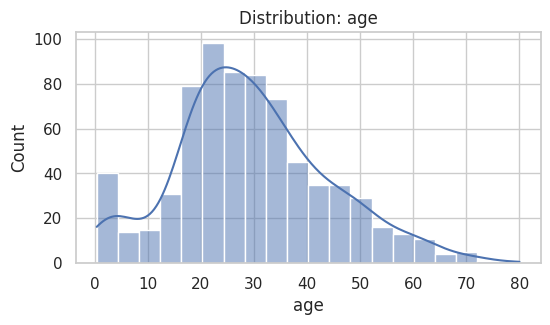

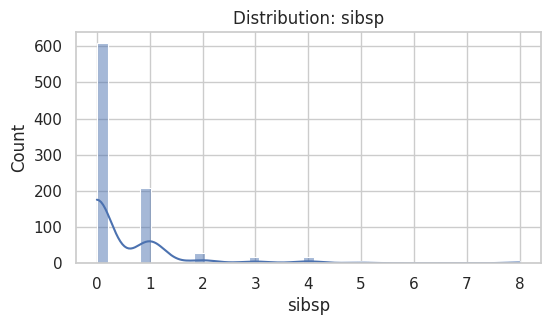

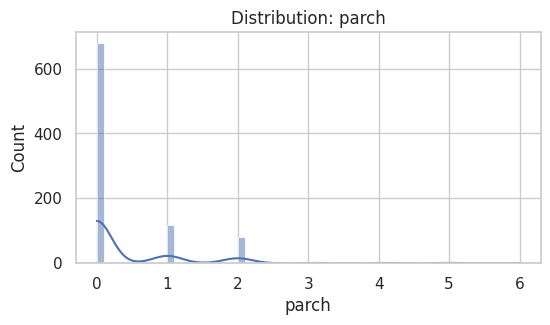

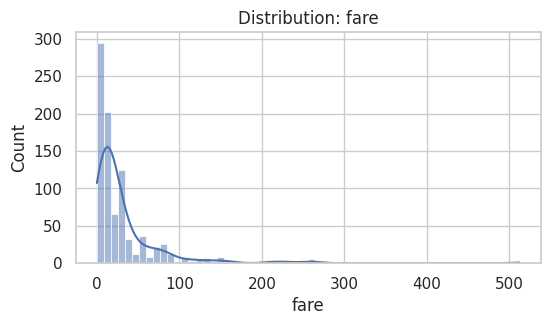

Skewness (higher => more right-skew):


fare      4.787317
sibsp     3.695352
parch     2.749117
age       0.389108
pclass   -0.630548
dtype: float64

In [26]:
# Visualize numeric distributions
num_cols_existing = [c for c in num_cols if c in X.columns]

for col in num_cols_existing:
    plt.figure(figsize=(6, 3))
    sns.histplot(X[col], kde=True)
    plt.title(f"Distribution: {col}")
    plt.show()

# Skewness (ignore NaNs)
skewness = X[num_cols_existing].skew(numeric_only=True).sort_values(ascending=False)
print("Skewness (higher => more right-skew):")
display(skewness)


,column,iqr_outliers,missing
3,parch,213,0
4,fare,116,0
2,sibsp,46,0
1,age,11,177
0,pclass,0,0


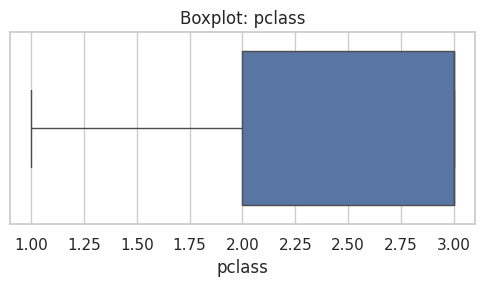

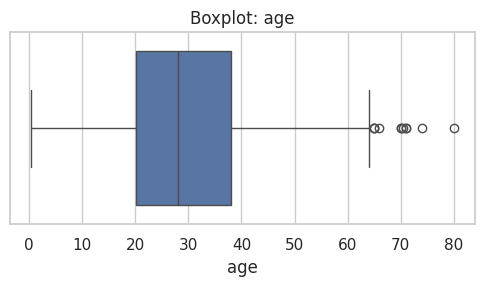

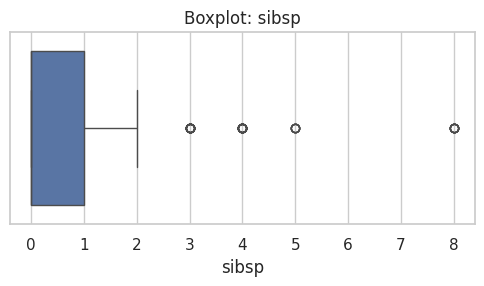

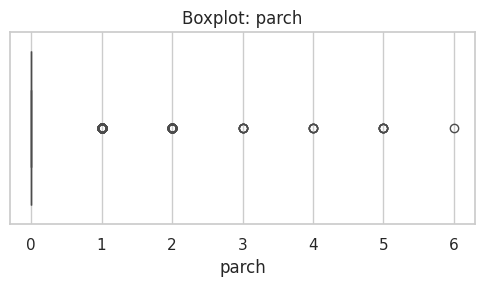

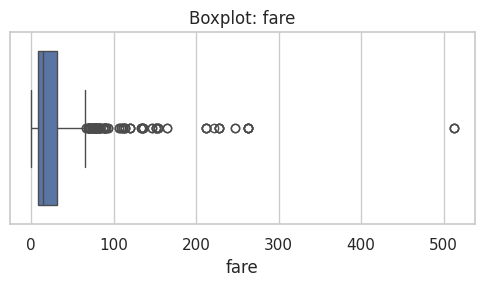

In [27]:
# Outlier detection using IQR rule (for numeric columns)

def iqr_outlier_counts(series: pd.Series):
    s = series.dropna()
    if s.empty:
        return 0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

outlier_table = []
for col in num_cols_existing:
    outlier_table.append({
        'column': col,
        'iqr_outliers': iqr_outlier_counts(X[col]),
        'missing': int(X[col].isna().sum())
    })

outlier_table = pd.DataFrame(outlier_table).sort_values('iqr_outliers', ascending=False)
display(outlier_table)

# Boxplots for a few numeric columns to visualize outliers
for col in num_cols_existing[:5]:
    plt.figure(figsize=(6, 2.5))
    sns.boxplot(x=X[col])
    plt.title(f"Boxplot: {col}")
    plt.show()


### What we will do for numeric preprocessing
Common baseline choice:
- Impute numeric missing with **median** (robust)
- Use **RobustScaler** if we expect outliers
- Optionally apply **log transform** to heavy skew features like `fare`

We will implement log transform carefully:
- use `log1p(x)` to handle zeros
- apply only to chosen columns
- keep everything inside the pipeline (fit on train only)


## 10 Train/Test Split (VERY IMPORTANT)

This is where most beginners unknowingly cheat.

### Correct rule
✅ Split first → then fit imputers/encoders/scalers only on training data.

### What leakage looks like
If you impute Age using the median computed on the full dataset, the test set influences your preprocessing.
That makes your evaluation overly optimistic.

We will:
- split with stratification (because classification)
- build pipelines that fit ONLY on training


In [22]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target proportion:")
display(y_train.value_counts(normalize=True))
print("Test target proportion:")
display(y_test.value_counts(normalize=True))


Train shape: (712, 14) Test shape: (179, 14)
Train target proportion:


survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test target proportion:


survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

In [28]:
# Leakage demonstration (DO NOT DO THIS IN REAL LIFE)
# We'll show how full-data imputation differs from train-only imputation.

if 'age' in X.columns:
    full_median_age = X['age'].median()
    train_median_age = X_train['age'].median()
    print("Full-data median age:", full_median_age)
    print("Train-only median age:", train_median_age)
    print("Difference (this difference is leakage if you use full-data median):", full_median_age - train_median_age)
else:
    print("No 'age' column found; leakage demo skipped.")


Full-data median age: 28.0
Train-only median age: 28.5
Difference (this difference is leakage if you use full-data median): -0.5


## 1️⃣1️⃣ Pipeline Construction
We will build a full preprocessing pipeline using:

- **ColumnTransformer** to apply different transformations to numeric vs categorical columns
- **Pipeline** to chain steps safely

Key requirements:
- Fit ONLY on training data
- Transform test data without refitting
- Handle missing values
- Encode categoricals safely
- Optionally transform skewed numeric columns (fare)

### Step-by-step plan
1. Decide which columns to drop (high-missing, unstable, leakage-prone)
2. Define numeric pipeline (impute → optional log → scale)
3. Define categorical pipeline (impute → one-hot)
4. Combine with ColumnTransformer
5. Fit on X_train only
6. Transform X_train and X_test


In [ ]:
# 1) Decide columns to drop
# We drop columns that are:
# - extremely missing (e.g., 'deck' often very missing)
# - high-cardinality proxies / unstable identifiers
#
# IMPORTANT: This is a teaching choice. In a real project, you would justify with business/clinical value.

drop_cols = []

# Example: seaborn Titanic contains 'deck' (often very missing). We'll drop it if missing is high.
if 'deck' in X.columns:
    if X['deck'].isna().mean() > 0.4:
        drop_cols.append('deck')

# Another common high-cardinality / less stable column: 'embark_town' duplicates 'embarked'
if 'embark_town' in X.columns and 'embarked' in X.columns:
    drop_cols.append('embark_town')

# 'alive' is basically the target in string form (leakage!) in seaborn dataset
if 'alive' in X.columns:
    drop_cols.append('alive')

print("Dropping columns:", drop_cols)

X_train2 = X_train.drop(columns=drop_cols, errors='ignore')
X_test2  = X_test.drop(columns=drop_cols, errors='ignore')

# Recompute column groups after dropping
cat_cols2 = X_train2.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols2 = X_train2.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns (pipeline):", cat_cols2)
print("Numerical columns (pipeline):", num_cols2)


In [ ]:
# 2) Numeric pipeline
# Steps:
# - impute missing numeric values with median (robust)
# - optional log transform for skewed 'fare' if present
# - scale using RobustScaler (less sensitive to outliers)

# We'll apply log1p only to selected columns (fare is the classic example)
log_transform_cols = [c for c in ['fare'] if c in num_cols2]

def log1p_selected(X_array, feature_names=None, log_cols_idx=None):
    """Apply log1p to selected column indices in a numpy array."""
    X_array = X_array.copy()
    if log_cols_idx is None or len(log_cols_idx) == 0:
        return X_array
    # log1p requires non-negative values
    for idx in log_cols_idx:
        col = X_array[:, idx]
        # clip negatives to 0 for safety (in real projects you'd investigate negatives)
        col = np.clip(col, a_min=0, a_max=None)
        X_array[:, idx] = np.log1p(col)
    return X_array

# We'll build the numeric pipeline after we know the indices of columns inside the numeric matrix.
# Since ColumnTransformer feeds only numeric columns into numeric pipeline in the same order,
# indices correspond to num_cols2 order.
log_cols_idx = [num_cols2.index(c) for c in log_transform_cols]

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    # add_indicator=True adds missingness indicators for numeric features automatically
    ('log1p', FunctionTransformer(log1p_selected, kw_args={'log_cols_idx': log_cols_idx}, validate=False)),
    ('scaler', RobustScaler())
])

# 3) Categorical pipeline
# - impute with most_frequent
# - one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4) Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols2),
        ('cat', categorical_pipeline, cat_cols2)
    ],
    remainder='drop'
)

preprocessor


### Explain every line (what just happened)

**`drop_cols`**: we removed columns that are likely harmful:
- `alive` is leakage (string version of survived)
- `deck` often too missing (unless you engineer it carefully)
- `embark_town` duplicates `embarked`

**Numeric pipeline**
- `SimpleImputer(strategy='median')`: replaces missing numeric values using training median only.
- `add_indicator=True`: creates extra features like `age_missing` if age had NaNs.
- `FunctionTransformer(log1p_selected)`: applies log transform only to selected numeric columns (like fare).
- `RobustScaler`: scales using median and IQR, less sensitive to outliers.

**Categorical pipeline**
- `most_frequent`: fills missing categorical with the most common category.
- `OneHotEncoder(handle_unknown='ignore')`: safe for categories appearing only in test.

**ColumnTransformer**
- sends numeric columns to numeric pipeline
- sends categorical columns to categorical pipeline
- drops everything else

Most importantly:
✅ We will **fit** this on `X_train2` only.


In [ ]:
# Fit ONLY on training data
X_train_ready = preprocessor.fit_transform(X_train2)
X_test_ready = preprocessor.transform(X_test2)

print("Transformed train shape:", X_train_ready.shape)
print("Transformed test shape:", X_test_ready.shape)

# Confirm no missing values in the transformed matrices
def count_nans_in_matrix(M):
    # Works for numpy arrays or sparse matrices
    if hasattr(M, 'toarray'):
        A = M.toarray()
        return np.isnan(A).sum()
    return np.isnan(M).sum()

print("NaNs in train matrix:", count_nans_in_matrix(X_train_ready))
print("NaNs in test matrix:", count_nans_in_matrix(X_test_ready))


## 1️⃣2️⃣ Final ML-Ready Dataset
We will now:
- confirm final shapes
- inspect feature names (important for debugging)
- confirm all values are numeric
- run basic sanity checks


In [ ]:
# Get feature names out of the pipeline
# Note: feature name extraction depends on scikit-learn version.

feature_names = []

# Numeric feature names: original numeric columns + missing indicators
# SimpleImputer(add_indicator=True) adds indicators with names like 'x0_missing'
# We'll attempt a robust extraction:

try:
    # Works in many sklearn versions
    feature_names = preprocessor.get_feature_names_out()
    feature_names = feature_names.tolist()
except Exception as e:
    print("Feature name extraction not supported in this sklearn version:", repr(e))
    feature_names = None

if feature_names is not None:
    print("Number of features:", len(feature_names))
    print("Sample feature names:")
    display(feature_names[:30])

# Create a small dense preview for sanity (careful: one-hot makes it big)
def to_dense_preview(M, n_rows=5):
    if hasattr(M, 'toarray'):
        return M.toarray()[:n_rows]
    return M[:n_rows]

preview = to_dense_preview(X_train_ready, n_rows=5)
print("Preview matrix shape:", preview.shape)
display(pd.DataFrame(preview, columns=feature_names[:preview.shape[1]] if feature_names else None).head())


In [ ]:
# Additional sanity checks

# 1) Check for infinite values
def count_infs_in_matrix(M):
    if hasattr(M, 'toarray'):
        A = M.toarray()
        return np.isinf(A).sum()
    return np.isinf(M).sum()

print("Infs in train:", count_infs_in_matrix(X_train_ready))
print("Infs in test:", count_infs_in_matrix(X_test_ready))

# 2) Check value ranges for a numeric sanity glance (dense sample)
A = to_dense_preview(X_train_ready, n_rows=min(200, X_train_ready.shape[0]))
print("Dense sample min:", np.min(A), "max:", np.max(A))


## 1️⃣3️⃣ Common Beginner Mistakes (Markdown Box)

> ✅ **Read this before you touch a real dataset.**

### 🚫 Mistake 1: Fitting preprocessors on the full dataset
- Example: scaling or imputing before train/test split
- Result: leakage, inflated evaluation

### 🚫 Mistake 2: Encoding categoricals before splitting
- Especially target encoding
- You accidentally let the test distribution influence training features

### 🚫 Mistake 3: Arbitrary imputations without reasoning
- “Fill Age with 0” or “Fill Fare with mean” without checking skew/outliers

### 🚫 Mistake 4: Ignoring semantic meaning
- Treating ID-like columns as categories
- Treating a categorical code as a numeric magnitude

### 🚫 Mistake 5: One-hot encoding extremely high-cardinality columns
- Your feature space explodes, training becomes unstable

### 🚫 Mistake 6: Removing outliers blindly
- Outliers might be real and important
- Removing them can bias your population

### 🚫 Mistake 7: Forgetting to handle unknown categories in test
- Without `handle_unknown='ignore'`, your pipeline can crash in production


## 1️⃣4️⃣ Guided Exercises (with TODO cells)
These exercises are designed to force you to **make decisions** and observe consequences.

Work directly in the TODO cells.


In [ ]:
# TODO 1: Try a different numeric imputation strategy
# - Replace median with mean
# - Fit on train only
# - Compare: does it change the transformed values distribution? (especially if outliers exist)

# Hint: change SimpleImputer(strategy='median') to strategy='mean'

# YOUR CODE HERE
pass


In [ ]:
# TODO 2: Remove 'fare' log transform and see the effect
# - Set log_transform_cols = []
# - Refit preprocessor on train
# - Compare distribution of the (scaled) fare feature before and after

# YOUR CODE HERE
pass


In [ ]:
# TODO 3: Try StandardScaler instead of RobustScaler
# - Replace RobustScaler() with StandardScaler()
# - Refit on train
# - Reason: which scaler is more sensitive to outliers? Can you observe differences?

# YOUR CODE HERE
pass


In [ ]:
# TODO 4: Rare category handling
# Implement a simple rare-category grouper for a categorical column.
# Example idea:
# - Choose a categorical column with several categories (like 'embarked' or 'who' or 'class')
# - Replace categories with frequency < 1% by 'Other'
# - Then one-hot encode
#
# Note: This must be done carefully to avoid leakage (fit the grouping on train only).

# YOUR CODE HERE
pass


## 1️⃣5️⃣ Reflection Questions
Write your answers (short paragraphs) after finishing the exercises.

1. Why can preprocessing be more important than the model?
2. Which preprocessing decision in this notebook was the most subjective? Why?
3. If this system went into production, what new preprocessing problems might appear?
4. Which features might be unstable over time (data drift) and how would you detect that?
5. What would you change if the goal was fairness (e.g., reducing bias across groups)?
6. What would you change if the dataset was 100x larger?
